In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import syllables
from collections import Counter
from collections import defaultdict
import random
import pyphen


In [4]:
# Wikipedia has multiple tables, so order we use pandas to read them all
url = "https://en.wikipedia.org/wiki/List_of_Y_Combinator_startups"

tables = pd.read_html(url)  # This returns a list of DataFrames

# Check how many tables were found
print(f"Found {len(tables)} tables")

# Let's preview the first few rows of the first few tables
for i, table in enumerate(tables[:3]):
    print(f"\n--- Table {i} ---")
    print(table.head())


Found 2 tables

--- Table 0 ---
           vteY Combinator                                  vteY Combinator.1
0        Founding Partners  Paul Graham Jessica Livingston Robert Morris T...
1  Partners (past/present)  Adora Cheung Dalton Caldwell Daniel Gross Emme...
2    Y Combinator startups  2005−2006 Clustrix Loopt OMGPop Reddit Scribd ...
3                2005−2006    Clustrix Loopt OMGPop Reddit Scribd Xobni YouOS
4                2007–2008  280 North AppJet Biographicon Disqus Dropbox H...

--- Table 1 ---
           0                                                  1
0  2005−2006    Clustrix Loopt OMGPop Reddit Scribd Xobni YouOS
1  2007–2008  280 North AppJet Biographicon Disqus Dropbox H...
2  2009−2010  1000Memories Airbnb Bump Homejoy Listia Mixpan...
3       2011  Circle Codecademy DrChrono Firebase HackerRank...
4       2012  9GAG Boosted BufferBox Canopy Labs Coinbase Di...


In [5]:
# Get the correct table
yc_table = tables[1]

# Extract company names from column 1 (second column)
company_col = yc_table[1]

# Split names by space and flatten
companies = []
for entry in company_col.dropna():
    # Each cell is a string of space-separated names
    names = entry.split()
    companies.extend(names)

print(f"Extracted {len(companies)} company names.")
print(companies[:20])


Extracted 147 company names.
['Clustrix', 'Loopt', 'OMGPop', 'Reddit', 'Scribd', 'Xobni', 'YouOS', '280', 'North', 'AppJet', 'Biographicon', 'Disqus', 'Dropbox', 'Heroku', 'Justin.tv', 'Ninite', 'Octopart', 'Parakey', 'Posterous', 'Songkick']


In [6]:
companies = [name.strip().lower() for name in companies if isinstance(name, str)]

In [7]:
df = pd.DataFrame({'company': companies})
df.to_csv("yc_companies.csv", index=False)

In [8]:
# Assuming you already have the list
df = pd.DataFrame({'company': companies})

# Length of each name
df['char_len'] = df['company'].apply(len)

# Word count
df['word_count'] = df['company'].apply(lambda x: len(x.split()))

# Starts with capital? Ends with vowel?
df['starts_cap'] = df['company'].apply(lambda x: x[0].isupper())
df['ends_vowel'] = df['company'].apply(lambda x: x[-1].lower() in 'aeiou')

# Preview
df.head()


,company,char_len,word_count,starts_cap,ends_vowel
0,clustrix,8,1,False,False
1,loopt,5,1,False,False
2,omgpop,6,1,False,False
3,reddit,6,1,False,False
4,scribd,6,1,False,False


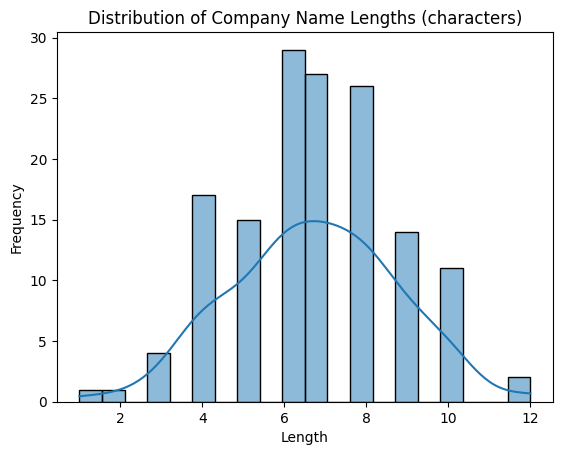

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['char_len'], bins=20, kde=True)
plt.title("Distribution of Company Name Lengths (characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


In [10]:
df['syllables'] = df['company'].apply(lambda x: syllables.estimate(x))
df[['company', 'syllables']].head()


,company,syllables
0,clustrix,2
1,loopt,1
2,omgpop,2
3,reddit,2
4,scribd,1


In [11]:
#To see trends like names ending in “ly”, “io”, “ify”:

suffixes = [name[-3:].lower() forimport pandas as pd
import pandas as pd
import pandas as pd
 name in companies if len(name) >= 3]
Counter(suffixes).most_common(10)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1328422526.py, line 3)

In [12]:
#And for prefixes
prefixes = [name[:3].lower() for name in companies if len(name) >= 3]
Counter(prefixes).most_common(10)


[('par', 3),
 ('air', 3),
 ('loo', 2),
 ('str', 2),
 ('zen', 2),
 ('cod', 2),
 ('hac', 2),
 ('boo', 2),
 ('len', 2),
 ('pla', 2)]

In [13]:
# Load names
df = pd.read_csv("yc_companies.csv", header=None)
names = df[0].dropna().unique().tolist()
names = [name.strip().lower() for name in names if len(name.split()) == 1 and name.isalpha()]

# Build a Markov chain
def build_chain(names, order=2):
    chain = defaultdict(list)
    for name in names:
        padded = "~" * order + name + "~"
        for i in range(len(name) + 1):
            key = padded[i:i+order]
            next_char = padded[i+order]
            chain[key].append(next_char)
    return chain

# Generate a name from the chain
# increase order=3 for more realism (breaks) or tweak max_length
def generate_name(chain, order=2, max_length=7):
    name = "~" * order
    while True:
        key = name[-order:]
        next_chars = chain.get(key)
        if not next_chars:
            break
        next_char = random.choice(next_chars)
        if next_char == "~":
            break
        name += next_char
        if len(name) > order + max_length:
            break
    return name[order:].capitalize()

# Build and test
chain = build_chain(names, order=2)

for _ in range(10):
    print(generate_name(chain))


Strikick
Stimick
Nink
Sont
Te
Biomi
Tercenom
Omgposto
Com
Gencoing


In [15]:
# Initialize Pyphen for English
dic = pyphen.Pyphen(lang='en')

# Load names
df = pd.read_csv("yc_companies.csv", header=None)
names = df[0].dropna().unique().tolist()
names = [name.strip().lower() for name in names if len(name.split()) == 1 and name.isalpha()]

# Syllable splitter
def get_syllables(word):
    return dic.inserted(word).split('-')

# Filter and store syllable breakdowns
syllables = [get_syllables(name) for name in names if len(name) >= 4]
syllables = [s for s in syllables if len(s) >= 2]  # Must have at least 2 syllables

In [16]:
def blend_syllables(syllables, max_syllables=3):
    s1 = random.choice(syllables)
    s2 = random.choice(syllables)
    # Choose first part from s1, second part from s2
    part1 = s1[:random.randint(1, len(s1)-1)]
    part2 = s2[random.randint(1, len(s2)-1):]
    new_name = ''.join(part1 + part2)
    return new_name.capitalize()

# Generate some
for _ in range(10):
    print(blend_syllables(syllables))


Booscord
Conizely
Coinchange
Doordup
Uppad
Ingrid
Airtimizely
Gitstacart
Scisolve
Exsql


In [17]:
def is_pronounceable(word):
    # Avoid 3+ consonants or vowels in a row
    return not re.search(r'[bcdfghjklmnpqrstvwxyz]{3,}', word) and \
           not re.search(r'[aeiou]{3,}', word)


In [176]:
def blend_syllables_clean(syllables, max_attempts=10):
    for _ in range(max_attempts):
        s1 = random.choice(syllables)
        s2 = random.choic
e(syllables)
        part1 = s1[:random.randint(1, len(s1)-1)]
        part2 = s2[random.randint(1, len(s2)-1):]
        new_name = ''.join(part1 + part2)
        if is_pronounceable(new_name):
            return new_name.capitalize()
    return None  # fallback


IndentationError: unindent does not match any outer indentation level (<string>, line 11)

In [189]:
# Generate some
for _ in range(20):

    print(blend_syllables(syllables))

Octed
Youous
Teeterous
Zidted
Experijoy
Zacialcam
Posduty
Bufal
Planted
Airmart
Exlab
Algolab
Apbel
Techpany
Youpop
Ripany
Coingraphicon
Upster
Writesonaspora
Zennb
